# Example 13: Melting line of Cu by dynamic Clausius-Clapeyron integration

In this example the melting line of Cu is traced from 0 bar to 50 kbar in a single pair of nonequilibrium runs with `mode: dcci`, the dynamic Clausius-Clapeyron integration of [de Koning, Antonelli and Yip, J. Chem. Phys. 115, 11025 (2001)](https://doi.org/10.1063/1.1420486).

The EAM potential is the same as in the melting-temperature examples: [Mishin, Y., M. J. Mehl, D. A. Papaconstantopoulos, A. F. Voter, and J. D. Kress, Physical Review B 63, 224106 (2001)](https://doi.org/10.1103/PhysRevB.63.224106).

The method needs one known coexistence point. Here it is the melting temperature at 0 bar from a `melting_temperature` calculation (example 04), 1340 K. From there a solid and a liquid cell are driven side by side at a fixed kinetic temperature with the scaled Hamiltonian $K + \lambda U$ of reversible scaling; the scaled pressure $P_{RS}$ of both cells is ramped linearly, and after every block of `n_block_steps` MD steps the scaling factor is updated from the block averages of the potential energy $u$ and volume $v$ per atom of the two cells,

$$\frac{d\lambda}{dP_{RS}} = -\frac{v_s - v_l}{u_s - u_l},$$

which is the Clausius-Clapeyron equation in the scaled variables. Every block is a point $T = T_0/\lambda$, $P = P_{RS}/\lambda$ of the melting line. A backward sweep returns to 0 bar; the line is the mean of both directions and the mismatch of the round trip is the hysteresis of the integration. The input file is provided in the folder:

```
mode: dcci
temperature: 1340.0
pressure: [0.0, 50000.0]
n_switching_steps: 30000
dcci:
  n_block_steps: 500
```

and is run with `calphy -i input.yaml`. The sweep stops once the real pressure reaches 50 kbar, after 53 of the 60 blocks; out and back it takes a few minutes on four cores. Two further inputs integrate the same line with other settings: `input_converged.yaml` to 100 kbar with 200 blocks of 500 steps (the sweep stops after 155 once the real pressure reaches 100 kbar), and `input_high.yaml` to 1.5 Mbar with 1000-step blocks, which stops after 29 blocks because the real pressure runs far ahead of the scaled ramp there.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from calphy.postprocessing import read_coexistence_line

The result is written to `coexistence_line.dat` in the calculation folder; `report.yaml` summarises it.

In [2]:
folder = "dcci-fcc-solid-1340-0"

with open(f"{folder}/report.yaml") as fin:
    report = yaml.safe_load(fin)
report["results"]

{'coexistence_line': 'coexistence_line.dat',
 'error_at_pressure_reached': 0.0,
 'hysteresis': 0.2081550000000334,
 'hysteresis_high': False,
 'n_blocks_used': 53,
 'pressure_reached': 51028.767473,
 'temperature_at_pressure_reached': 1548.193549,
 'unit': 'K, bar'}

The round trip returns to within a fraction of a kelvin of the starting temperature, so the integration is reversible at this sweep length. The line itself, every tenth block:

In [3]:
line = read_coexistence_line(folder)
line.iloc[::10]

,pressure,temperature,error,temperature_forward,temperature_backward
0,0.000000,1340.104078,0.104078,1340.000000,1340.208155
10,8561.375847,1376.695404,0.026168,1376.669236,1376.721573
20,17592.443153,1414.460120,0.027691,1414.432429,1414.487811
30,27115.657682,1453.499545,0.100293,1453.399252,1453.599839
40,37158.070449,1493.804410,0.049978,1493.754432,1493.854389
50,47743.533128,1535.466258,0.034233,1535.432025,1535.500491


The other two runs report their hysteresis in the same way; the 155-block run closes to a hundredth of a kelvin:

In [4]:
folder_conv = "dcci-fcc-solid-1340-0-converged"
folder_high = "dcci-fcc-solid-1340-0-high"

line_conv = read_coexistence_line(folder_conv)
line_high = read_coexistence_line(folder_high)
with open(f"{folder_high}/report.yaml") as fin:
    report_high = yaml.safe_load(fin)
report_high["results"]

{'coexistence_line': 'coexistence_line.dat',
 'error_at_pressure_reached': 0.0,
 'hysteresis': 2.4347530000000006,
 'hysteresis_high': False,
 'n_blocks_used': 29,
 'pressure_reached': 1580250.711377,
 'temperature_at_pressure_reached': 4867.898743,
 'unit': 'K, bar'}

To check the lines, the melting point was calculated independently at several pressures in two ways: with `mode: melting_temperature` (the input files `tm.input.*.yaml` are in the folder), and by direct free-energy calculations of both phases at two temperatures bracketing the melting point, whose crossing of $G_l - G_s$ gives $T_m$ with an error bar. Each of those points costs more than a whole coexistence line.

In [5]:
with open("melting_temperature_reference.yaml") as fin:
    reference = yaml.safe_load(fin)
reference

[{'pressure': 0.0,
  'tm': 1340.6,
  'tm_error': 0.0,
  'method': 'melting_temperature'},
 {'pressure': 50000.0,
  'tm': 1564.9,
  'tm_error': 0.0,
  'method': 'melting_temperature'},
 {'pressure': 100000.0,
  'tm': 1776.3,
  'tm_error': 0.0,
  'method': 'melting_temperature'},
 {'pressure': 500000.0,
  'tm': 2912.9,
  'tm_error': 0.0,
  'method': 'melting_temperature'},
 {'pressure': 0.0, 'tm': 1353.3, 'tm_error': 1.9, 'method': 'fe_crossing'},
 {'pressure': 50000.0, 'tm': 1559.9, 'tm_error': 1.6, 'method': 'fe_crossing'},
 {'pressure': 100000.0,
  'tm': 1749.2,
  'tm_error': 3.4,
  'method': 'fe_crossing'}]

As in example 05 we also compare with Simon-equation fits, $T_m(P) = T_{m0}(P/a + 1)^b$, reported for this potential by [Wang et al. (2013)](https://doi.org/10.1063/1.4798225) and by An et al.:

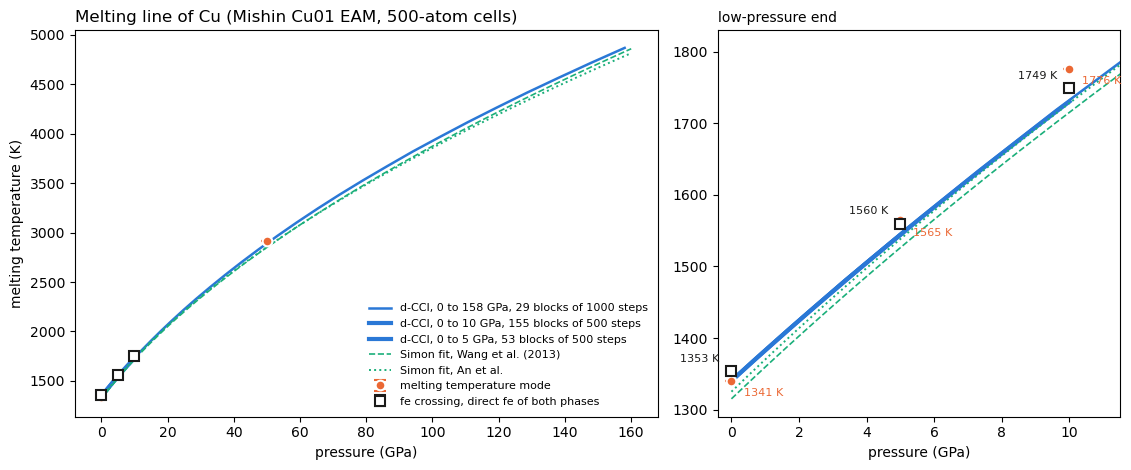

In [6]:
def simon(p_gpa, tm0, a, b):
    return tm0 * (p_gpa / a + 1) ** b

GPA = 1e-4  # bar -> GPa
BLUE, ORANGE, INK, AQUA = "#2a78d6", "#eb6834", "#1a1a19", "#1baf7a"

def draw(ax, zoom):
    for df, lw, label in ((line_high, 1.8, "d-CCI, 0 to 158 GPa, 29 blocks of 1000 steps"),
                          (line_conv, 3.0, "d-CCI, 0 to 10 GPa, 155 blocks of 500 steps"),
                          (line, 3.0, "d-CCI, 0 to 5 GPa, 53 blocks of 500 steps")):
        p = df.pressure * GPA
        ax.fill_between(p, df.temperature - df.error, df.temperature + df.error, color=BLUE, alpha=0.18, lw=0)
        ax.plot(p, df.temperature, color=BLUE, lw=lw, label=label)
    for method, fmt, color, mfc, dx in (("melting_temperature", "o", ORANGE, ORANGE, 9), ("fe_crossing", "s", INK, "white", -9)):
        pts = [r for r in reference if r["method"] == method]
        p = np.array([r["pressure"] for r in pts]) * GPA
        t = np.array([r["tm"] for r in pts])
        e = np.array([r["tm_error"] for r in pts])
        ax.errorbar(p, t, yerr=e, fmt=fmt, ms=7, color=color, mfc=mfc, mec=color if mfc == "white" else "white", mew=1.5,
                    ecolor=color, capsize=4, lw=1.2, zorder=5, label=method.replace("_", " ") + (" mode" if method == "melting_temperature" else ", direct fe of both phases"))
        if zoom:
            for pi, ti in zip(p, t):
                ax.annotate("%.0f K" % ti, (pi, ti), textcoords="offset points", xytext=(dx, -dx), fontsize=8,
                            color=color, ha="left" if dx > 0 else "right", va="center")
    pfit = np.linspace(0, 160, 300)
    ax.plot(pfit, simon(pfit, 1315, 15.84, 0.543), ls="--", lw=1.2, color=AQUA, label="Simon fit, Wang et al. (2013)")
    ax.plot(pfit, simon(pfit, 1325, 15.37, 0.53), ls=":", lw=1.4, color=AQUA, label="Simon fit, An et al.")
    ax.set_xlabel("pressure (GPa)")
    if zoom:
        ax.set_xlim(-0.4, 11.5); ax.set_ylim(1290, 1830); ax.set_title("low-pressure end", loc="left", fontsize=10)
    else:
        ax.set_ylabel("melting temperature (K)"); ax.set_title("Melting line of Cu (Mishin Cu01 EAM, 500-atom cells)", loc="left")
        ax.legend(frameon=False, fontsize=8, loc="lower right")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8), gridspec_kw={"width_ratios": [1.45, 1]})
draw(ax1, False); draw(ax2, True)
fig.tight_layout()
plt.savefig("melting_line.png", dpi=150, bbox_inches="tight")

The three d-CCI runs agree with each other (1544 K at 5 GPa from both the 53- and the 155-block run; 1719 K against 1730 K at 10 GPa from the 29- and the 155-block run), so the line is converged to about 10 K at 10 GPa with 500-step blocks, and it tracks the published Simon fits for this potential to within a few percent up to 160 GPa.

Against the direct free-energy crossings the d-CCI line runs about 1 percent low, and the whole offset is the starting point: the direct crossing at 0 bar is 1353 K where `melting_temperature` gave 1340 K, the value the integration started from. Scaling the line by 1353/1340 gives 1559 K at 5 GPa and 1747 K at 10 GPa against the direct 1560 K and 1749 K. The dynamic integration therefore reproduces the pressure dependence to within a few kelvin; its accuracy is set by the accuracy of the starting coexistence point, and an error there propagates roughly in proportion to $T/T_0$. The `melting_temperature` points scatter around the direct crossings by 10 to 30 K, which is the resolution of that mode at these short settings.

The slope of the line agrees with the Clausius-Clapeyron slope $\Delta H/(T\Delta V)$ written per block to `dcci.forward_1.dat`:

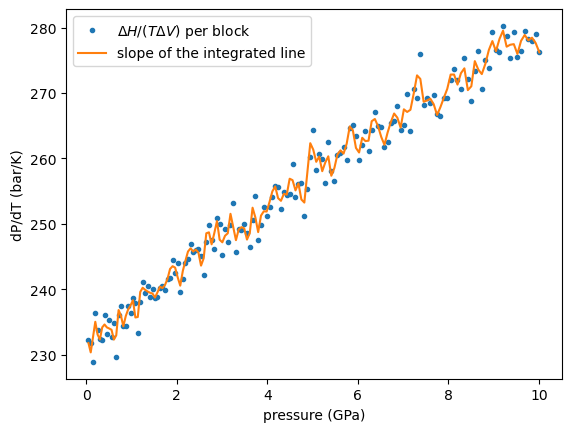

In [7]:
fwd = np.loadtxt(f"{folder_conv}/dcci.forward_1.dat")
temp, press, dpdt = fwd[:, 3], fwd[:, 5], fwd[:, 10]

fig, ax = plt.subplots()
ax.plot(press * GPA, dpdt, "o", ms=3, label=r"$\Delta H / (T \Delta V)$ per block")
ax.plot(press * GPA, np.gradient(press, temp), "-", label="slope of the integrated line")
ax.set_xlabel("pressure (GPa)")
ax.set_ylabel("dP/dT (bar/K)")
ax.legend();

Convergence is judged from the hysteresis: repeat with a longer `n_switching_steps` (or more `n_iterations`) until the round trip closes within the accuracy needed. The reference paper found the hysteresis to fall below the error of the starting point at about $10^5$ steps for a 500-atom Lennard-Jones system spanning two orders of magnitude in pressure.